In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/SecurityData.csv")
df.columns = df.columns.str.strip().str.lower()

date_cols = ['date', 'maturity_date', 'next_call_date']
for c in date_cols:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors='coerce')

num_cols = ['spread', 'duration', 'closing_price', 'ytm', 'current_yield', 'coupon_rate']
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

df = df[df['asset_type'].str.lower().isin(['credit', 'corporate', 'corp'])]

df = df.dropna(subset=['spread', 'duration'])
df = df.dropna(subset=['closing_price'])

if df['spread'].median() > 1:
    df['spread'] = df['spread'] / 10000.0

df = df[(df['duration'] > 0)]
df = df[df['closing_price'].between(20, 150)]

df = df.sort_values(['cusip', 'date'])
df = df.drop_duplicates(subset=['cusip', 'date'])

df['dts'] = df['spread'] * df['duration']
df = df[df['dts'] < df['dts'].quantile(0.999)]
df = df.reset_index(drop=True)

q1 = df['dts'].quantile(0.33)
q2 = df['dts'].quantile(0.66)

df['dts_bucket'] = pd.cut(
    df['dts'],
    bins=[-np.inf, q1, q2, np.inf],
    labels=['low', 'medium', 'high']
)

df = df.sort_values(['cusip','date'])
df['ret'] = df.groupby('cusip')['closing_price'].pct_change()
df = df.dropna(subset=['ret'])

d1 = df['duration'].quantile(0.33)
d2 = df['duration'].quantile(0.66)

df['duration_bucket'] = pd.cut(
    df['duration'],
    bins=[-np.inf, d1, d2, np.inf],
    labels=['short', 'medium', 'long']
)

dts_port = df.pivot_table(
    index='date',
    columns='dts_bucket',
    values='ret',
    aggfunc='mean'
)

dur_port = df.pivot_table(
    index='date',
    columns='duration_bucket',
    values='ret',
    aggfunc='mean'
)


/var/folders/59/hb0z0gw54v346g6175w3ns9r0000gp/T/ipykernel_91808/3436284956.py:57: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  dts_port = df.pivot_table(
/var/folders/59/hb0z0gw54v346g6175w3ns9r0000gp/T/ipykernel_91808/3436284956.py:64: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  dur_port = df.pivot_table(


In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

cdx_ig = pd.read_excel("../data/CDXIGSpread.xlsx")
cdx_hy = pd.read_excel("../data/CDXHYSpread.xlsx")

cdx_ig.columns = cdx_ig.columns.str.strip().str.lower()
cdx_hy.columns = cdx_hy.columns.str.strip().str.lower()

cdx_ig['date'] = pd.to_datetime(cdx_ig['date'], errors='coerce')
cdx_hy['date'] = pd.to_datetime(cdx_hy['date'], errors='coerce')

cdx_ig = cdx_ig.sort_values('date').set_index('date')
cdx_hy = cdx_hy.sort_values('date').set_index('date')

cdx_ig['ret'] = cdx_ig['5y'].pct_change()
cdx_hy['ret'] = cdx_hy['5y'].pct_change()

cdx_ig = cdx_ig.dropna(subset=['ret'])
cdx_hy = cdx_hy.dropna(subset=['ret'])

dts_merged = dts_port.merge(cdx_ig[['ret']], left_index=True, right_index=True, how='inner')
dts_merged = dts_merged.rename(columns={'ret': 'ig_ret'})
dts_merged = dts_merged.merge(cdx_hy[['ret']], left_index=True, right_index=True, how='inner')
dts_merged = dts_merged.rename(columns={'ret': 'hy_ret'})

dur_merged = dur_port.merge(cdx_ig[['ret']], left_index=True, right_index=True, how='inner')
dur_merged = dur_merged.rename(columns={'ret': 'ig_ret'})
dur_merged = dur_merged.merge(cdx_hy[['ret']], left_index=True, right_index=True, how='inner')
dur_merged = dur_merged.rename(columns={'ret': 'hy_ret'})

def beta_two_factor(y, x1, x2):
    X = np.column_stack([x1, x2])
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()
    return model.params[1], model.params[2]

betas = {}
for col in ['low','medium','high']:
    y = dts_merged[col]
    x1 = dts_merged['ig_ret']
    x2 = dts_merged['hy_ret']
    b_ig, b_hy = beta_two_factor(y, x1, x2)
    betas[col] = (b_ig, b_hy)


/var/folders/59/hb0z0gw54v346g6175w3ns9r0000gp/T/ipykernel_91808/1209211361.py:17: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  cdx_ig['ret'] = cdx_ig['5y'].pct_change()
/var/folders/59/hb0z0gw54v346g6175w3ns9r0000gp/T/ipykernel_91808/1209211361.py:18: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  cdx_hy['ret'] = cdx_hy['5y'].pct_change()
/var/folders/59/hb0z0gw54v346g6175w3ns9r0000gp/T/ipykernel_91808/1209211361.py:37: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavio

In [5]:
low = dts_port['low']
med = dts_port['medium']
high = dts_port['high']

ig = dts_merged['ig_ret']
hy = dts_merged['hy_ret']

bL_ig, bL_hy = betas['low']
bM_ig, bM_hy = betas['medium']
bH_ig, bH_hy = betas['high']

raw_dts = low - high

h_ig = -(bL_ig - bH_ig)
h_hy = -(bL_hy - bH_hy)

dts_hedged = raw_dts + h_ig * ig + h_hy * hy

dts_results = pd.DataFrame({
    'raw_dts': raw_dts,
    'dts_hedged': dts_hedged,
    'low': low,
    'medium': med,
    'high': high,
    'ig': ig,
    'hy': hy
})


In [6]:
short_dur = dur_port['short']
med_dur = dur_port['medium']
long_dur = dur_port['long']

ig2 = dur_merged['ig_ret']
hy2 = dur_merged['hy_ret']

def beta_two_factor(y, x1, x2):
    X = np.column_stack([x1, x2])
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()
    return model.params[1], model.params[2]

dur_betas = {}
for col in ['short','medium','long']:
    y = dur_merged[col]
    x1 = dur_merged['ig_ret']
    x2 = dur_merged['hy_ret']
    b_ig, b_hy = beta_two_factor(y, x1, x2)
    dur_betas[col] = (b_ig, b_hy)

bS_ig, bS_hy = dur_betas['short']
bM2_ig, bM2_hy = dur_betas['medium']
bL2_ig, bL2_hy = dur_betas['long']

raw_dur = short_dur - long_dur

h2_ig = -(bS_ig - bL2_ig)
h2_hy = -(bS_hy - bL2_hy)

dur_hedged = raw_dur + h2_ig * ig2 + h2_hy * hy2

dur_results = pd.DataFrame({
    'raw_dur': raw_dur,
    'dur_hedged': dur_hedged,
    'short': short_dur,
    'medium': med_dur,
    'long': long_dur,
    'ig': ig2,
    'hy': hy2
})


/var/folders/59/hb0z0gw54v346g6175w3ns9r0000gp/T/ipykernel_91808/2140732814.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return model.params[1], model.params[2]


In [7]:
import numpy as np
import pandas as pd

def cumulative_return(series):
    return (1 + series).cumprod()

def annualized_vol(series, periods=252):
    return series.std() * np.sqrt(periods)

def annualized_sharpe(series, periods=252):
    return series.mean() / series.std() * np.sqrt(periods)

def max_drawdown(cumret):
    peak = cumret.cummax()
    dd = (cumret - peak) / peak
    return dd.min()

dts_raw_cum = cumulative_return(dts_results['raw_dts'])
dts_hedged_cum = cumulative_return(dts_results['dts_hedged'])

dur_raw_cum = cumulative_return(dur_results['raw_dur'])
dur_hedged_cum = cumulative_return(dur_results['dur_hedged'])

perf = pd.DataFrame({
    'dts_raw_sharpe': [annualized_sharpe(dts_results['raw_dts'])],
    'dts_hedged_sharpe': [annualized_sharpe(dts_results['dts_hedged'])],
    'dur_raw_sharpe': [annualized_sharpe(dur_results['raw_dur'])],
    'dur_hedged_sharpe': [annualized_sharpe(dur_results['dur_hedged'])],
    'dts_raw_vol': [annualized_vol(dts_results['raw_dts'])],
    'dts_hedged_vol': [annualized_vol(dts_results['dts_hedged'])],
    'dur_raw_vol': [annualized_vol(dur_results['raw_dur'])],
    'dur_hedged_vol': [annualized_vol(dur_results['dur_hedged'])],
    'dts_raw_mdd': [max_drawdown(dts_raw_cum)],
    'dts_hedged_mdd': [max_drawdown(dts_hedged_cum)],
    'dur_raw_mdd': [max_drawdown(dur_raw_cum)],
    'dur_hedged_mdd': [max_drawdown(dur_hedged_cum)]
})


In [8]:
display(perf)

,dts_raw_sharpe,dts_hedged_sharpe,dur_raw_sharpe,dur_hedged_sharpe,dts_raw_vol,dts_hedged_vol,dur_raw_vol,dur_hedged_vol,dts_raw_mdd,dts_hedged_mdd,dur_raw_mdd,dur_hedged_mdd
0,0.195853,1.505626,0.079959,1.468727,0.25219,0.266748,0.26359,0.276974,-0.382546,-0.153645,-0.43385,-0.155084


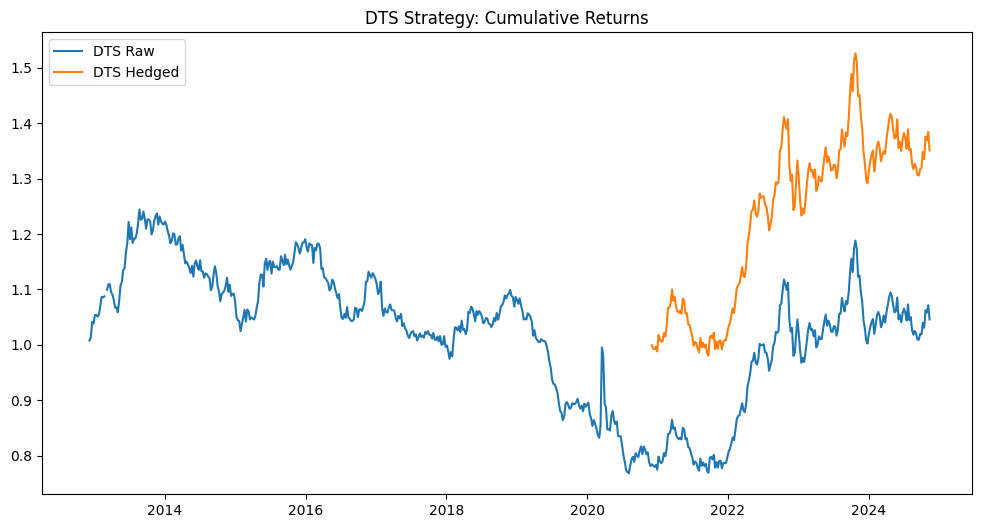

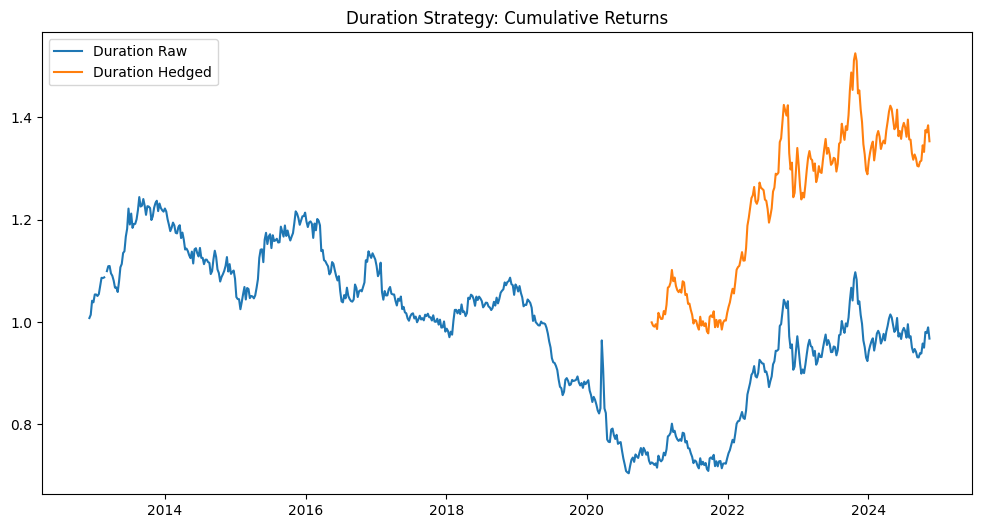

In [9]:
import matplotlib.pyplot as plt

dts_raw_cum = (1 + dts_results['raw_dts']).cumprod()
dts_hedged_cum = (1 + dts_results['dts_hedged']).cumprod()

dur_raw_cum = (1 + dur_results['raw_dur']).cumprod()
dur_hedged_cum = (1 + dur_results['dur_hedged']).cumprod()

plt.figure(figsize=(12,6))
plt.plot(dts_raw_cum, label='DTS Raw')
plt.plot(dts_hedged_cum, label='DTS Hedged')
plt.title('DTS Strategy: Cumulative Returns')
plt.legend()
plt.show()

plt.figure(figsize=(12,6))
plt.plot(dur_raw_cum, label='Duration Raw')
plt.plot(dur_hedged_cum, label='Duration Hedged')
plt.title('Duration Strategy: Cumulative Returns')
plt.legend()
plt.show()


In [10]:
dts_dur = df.groupby('dts_bucket')['duration'].mean()
dts_spread = df.groupby('dts_bucket')['spread'].mean()

dur_dur = df.groupby('duration_bucket')['duration'].mean()
dur_spread = df.groupby('duration_bucket')['spread'].mean()

dts_low_dur = dts_dur['low']
dts_high_dur = dts_dur['high']

dur_short_dur = dur_dur['short']
dur_long_dur = dur_dur['long']

dts_low_spread = dts_spread['low']
dts_high_spread = dts_spread['high']

dur_short_spread = dur_spread['short']
dur_long_spread = dur_spread['long']

ig_shock_100 = 0.01
ig_shock_200 = 0.02
hy_shock_100 = 0.01
hy_shock_200 = 0.02

rate_shock_50bp = 0.005

dts_stress = pd.DataFrame({
    'IG_+100bp': [-dts_low_dur*rate_shock_50bp + dts_low_spread*ig_shock_100,
                  dts_high_dur*rate_shock_50bp - dts_high_spread*ig_shock_100],
    'IG_+200bp': [-dts_low_dur*rate_shock_50bp + dts_low_spread*ig_shock_200,
                  dts_high_dur*rate_shock_50bp - dts_high_spread*ig_shock_200],
    'HY_+100bp': [-dts_low_dur*rate_shock_50bp + dts_low_spread*hy_shock_100,
                  dts_high_dur*rate_shock_50bp - dts_high_spread*hy_shock_100],
    'HY_+200bp': [-dts_low_dur*rate_shock_50bp + dts_low_spread*hy_shock_200,
                  dts_high_dur*rate_shock_50bp - dts_high_spread*hy_shock_200],
    'Rate_+50bp': [-dts_low_dur*rate_shock_50bp,
                   dts_high_dur*rate_shock_50bp]
}, index=['Low Bucket','High Bucket'])

dur_stress = pd.DataFrame({
    'IG_+100bp': [-dur_short_dur*rate_shock_50bp + dur_short_spread*ig_shock_100,
                  dur_long_dur*rate_shock_50bp - dur_long_spread*ig_shock_100],
    'IG_+200bp': [-dur_short_dur*rate_shock_50bp + dur_short_spread*ig_shock_200,
                  dur_long_dur*rate_shock_50bp - dur_long_spread*ig_shock_200],
    'HY_+100bp': [-dur_short_dur*rate_shock_50bp + dur_short_spread*hy_shock_100,
                  dur_long_dur*rate_shock_50bp - dur_long_spread*hy_shock_100],
    'HY_+200bp': [-dur_short_dur*rate_shock_50bp + dur_short_spread*hy_shock_200,
                  dur_long_dur*rate_shock_50bp - dur_long_spread*hy_shock_200],
    'Rate_+50bp': [-dur_short_dur*rate_shock_50bp,
                   dur_long_dur*rate_shock_50bp]
}, index=['Short Bucket','Long Bucket'])


/var/folders/59/hb0z0gw54v346g6175w3ns9r0000gp/T/ipykernel_91808/591648517.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dts_dur = df.groupby('dts_bucket')['duration'].mean()
/var/folders/59/hb0z0gw54v346g6175w3ns9r0000gp/T/ipykernel_91808/591648517.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dts_spread = df.groupby('dts_bucket')['spread'].mean()
/var/folders/59/hb0z0gw54v346g6175w3ns9r0000gp/T/ipykernel_91808/591648517.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or obse

In [11]:
display(dur_stress)

,IG_+100bp,IG_+200bp,HY_+100bp,HY_+200bp,Rate_+50bp
Short Bucket,-0.006644,-0.006544,-0.006644,-0.006544,-0.006744
Long Bucket,0.075206,0.075060,0.075206,0.075060,0.075352


In [12]:
dts_ret = dts_results['dts_hedged']
dur_ret = dur_results['dur_hedged']

dts_std = (dts_ret - dts_ret.mean()) / dts_ret.std()
dur_std = (dur_ret - dur_ret.mean()) / dur_ret.std()

combined = 0.5 * dts_std + 0.5 * dur_std

combined_cum = (1 + combined).cumprod()

def ann_vol(x):
    return x.std() * np.sqrt(252)

def ann_sharpe(x):
    return x.mean() / x.std() * np.sqrt(252)

def mdd(cum):
    peak = cum.cummax()
    return ((cum - peak) / peak).min()

combined_perf = pd.DataFrame({
    'combined_sharpe': [ann_sharpe(combined)],
    'combined_vol': [ann_vol(combined)],
    'combined_mdd': [mdd(combined_cum)],
    'dts_sharpe': [ann_sharpe(dts_ret)],
    'dur_sharpe': [ann_sharpe(dur_ret)]
})

combined_results = pd.DataFrame({
    'dts': dts_ret,
    'dur': dur_ret,
    'combined': combined,
    'combined_cum': combined_cum
})
